# Linear Regression

## The Linear Equation

# The r Squared Value 

## r square value = 1- ( Sum of E1^2 / Sum of E2^2)

In [1]:
from sklearn.metrics import r2_score
y = [1,2,3,4,5,6,7,8]
y1 = [.8, 2.5, 3,4.5,4.4,5.19,6.9,7.9] 
R_square = r2_score(y,y1)
print('Coefficient of Determination',R_square)

Coefficient of Determination 0.9624738095238096


# Practical Use of Simple Liner Regression

# Example 1

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df = pd.read_csv(r"C:\Users\HP\A  Self Pace ML\19. Simple Linear Regression\homeprices.csv") 
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


<Axes: xlabel='area', ylabel='price'>

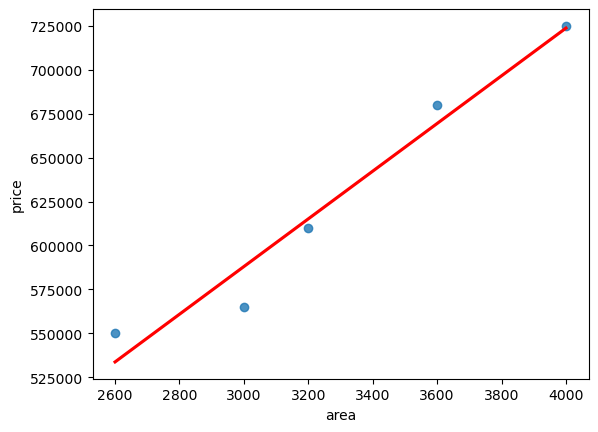

In [4]:
sns.regplot(data=df, x='area', y='price', ci=None, line_kws={'color': 'red'})

In [5]:
x = df[['area']]
y = df.price

In [6]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()  # create object to LinearRegression class 
reg.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
reg.predict([[3300]])

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [8]:
import pandas as pd

# Pass it as a DataFrame with the column name 'area'
reg.predict(pd.DataFrame([[3300]], columns=['area']))

array([628715.75342466])

In [9]:
reg.coef_ # this constant represents slope m 

array([135.78767123])

In [10]:
reg.intercept_

np.float64(180616.43835616432)

In [11]:
# maulally pridict house price
# price = m*area + b
price = 135.78767123*3300 + 180616.43835616432


In [12]:
price

628715.7534151643

In [13]:
reg.predict(pd.DataFrame([[5000]], columns=['area']))

array([859554.79452055])

In [14]:
from sklearn.metrics import r2_score
y_original = df.price
y_predicted = reg.predict(df[['area']])
R_square = r2_score(y_original, y_predicted) 
print('r square value', R_square)

r square value 0.9584301138199486


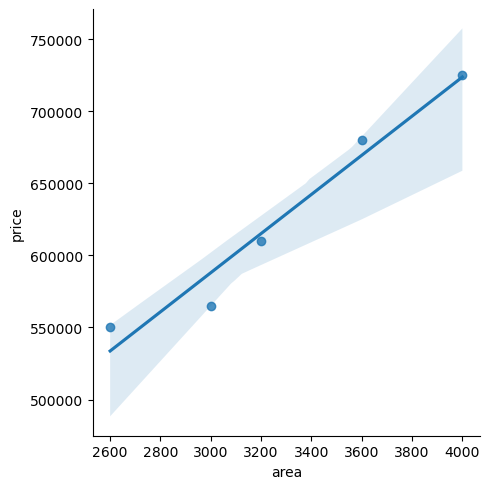

In [15]:
sns.lmplot(data=df, x='area' , y = 'price')

## Generate CSV file with list of home price predictions

In [16]:
import pandas as pd

# Create a clean dictionary with a list of values
data = {'area': [1000, 1500, 2300, 3540, 4120, 4560, 5490, 3460, 4750, 2300, 9000, 8600, 7100]}

# Load it into a DataFrame
area_df = pd.DataFrame(data)
area_df.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [17]:
p = reg.predict(area_df)
p

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [18]:
area_df['prices']=p
area_df

,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [19]:
area_df.to_csv("prediction.csv")

# Simple Linear Regression with Train and Test Data

In [20]:
reg = LinearRegression()
reg.fit(df[['area']],df.price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# selectic specific range for traing and testing the model 
from sklearn.model_selection import train_test_split
# using  test size as 30%
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state= 0 ) 


In [22]:
# # settinh test size as 30%
# x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=_size=.3, random_state= 0 ) 

In [23]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x_train, y_train) # train the model using train data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = reg.predict(x_test) 
y_pred

array([602500., 505000.])

In [25]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

-0.15625000000000666

In [26]:
# we get negtive bec of less data sizen Linear regression needs more data points to find a stable, reliable trend. 

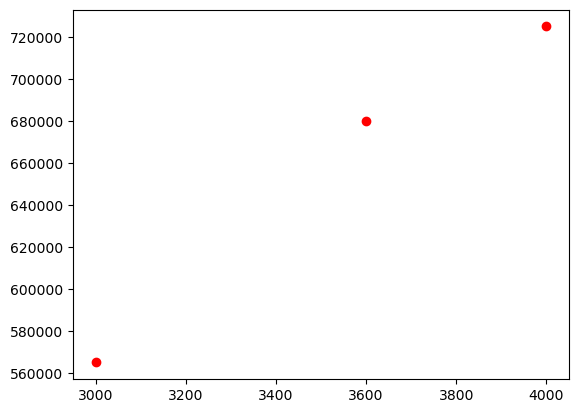

In [27]:
plt.scatter(x_train, y_train, color = 'red')

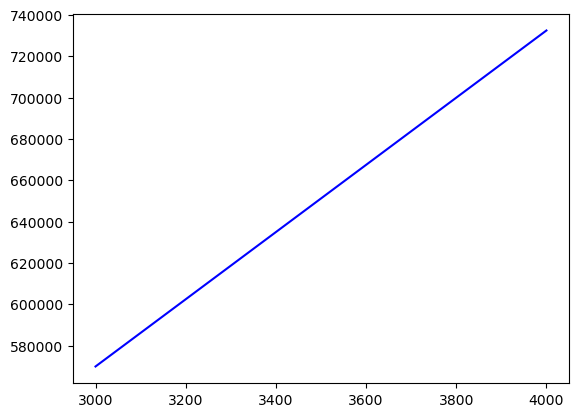

In [28]:
plt.plot(x_train, reg.predict(x_train), color = 'blue')

# Exercise 2

### The dataset salary_data.csv

In [29]:
import pandas as pd

# Load and verify the dataset
salary_data = pd.read_csv('salary_data.csv')
print(salary_data.shape) 
print(salary_data.head(10))

(30, 2)
   YearsExperience  Salary
0              4.6   76138
1             10.0  133721
2              8.0  110339
3              6.7   99859
4              2.6   60384
5              2.6   72654
6              1.6   54075
7              9.2  119154
8              6.8  106355
9              7.8  105388


In [30]:
x = salary_data[['YearsExperience']]
y = salary_data[['Salary']]

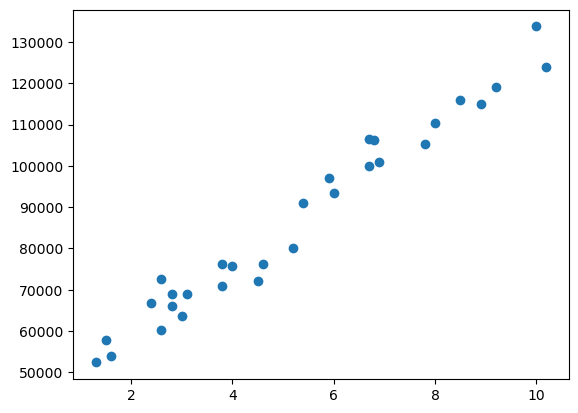

In [31]:
plt.scatter(x,y)

In [32]:
# take 70% of data for training and 30% for testing 
# random_state indicates the random seed used in selecting test rows 
from sklearn.model_selection import train_test_split
x_train, x_test ,y_train, y_test = train_test_split(x , y, test_size=.3, random_state= 0)

In [33]:
# train the computer with simple Linear Regression Model 
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [34]:
# train the model by passing train data to fit method 
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# train the model by passing test daa and obtain predicted data 
y_pred = reg.predict(x_test)

In [36]:
y_pred

array([[110161.03040413],
       [ 99102.19384622],
       [ 68477.72337815],
       [ 53165.48814411],
       [ 67627.04364292],
       [ 88043.3572883 ],
       [ 92296.75596442],
       [128875.98457906],
       [ 93147.43569965]])

In [37]:
import pandas as pd

# Create a clean DataFrame using your test features
df_test_results = pd.DataFrame(x_test, columns=['YearsExperience'])

# Add the predictions to this new smaller DataFrame
df_test_results['ExpectedSalary'] = y_pred
df_test_results

,YearsExperience,ExpectedSalary
2,8.0,110161.030404
28,6.7,99102.193846
13,3.1,68477.723378
10,1.3,53165.488144
26,3.0,67627.043643
24,5.4,88043.357288
27,5.9,92296.755964
11,10.2,128875.984579
17,6.0,93147.435700


In [38]:
# find the r squared value by comparing test data 
# (expected data) and predicted data. Accuracy is 97.4% 
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9717172386224335

In [39]:
# predict the salary of employee with experiene 11 Years .
print(reg.predict(pd.DataFrame([[11]], columns=['YearsExperience'])))

[[135681.42246085]]


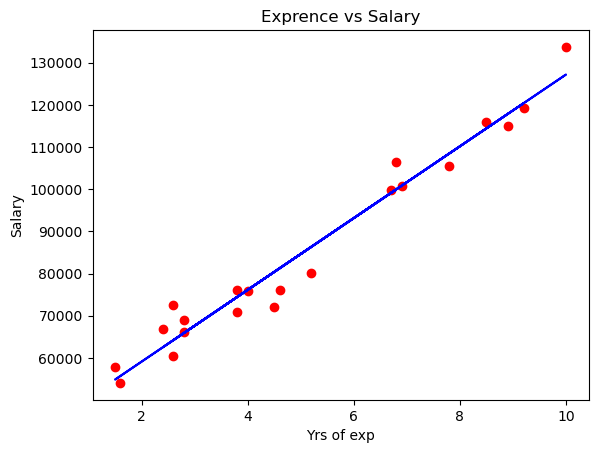

In [40]:
#using matplotlib,draw scatter plot and line plot 
# select the below all statements and then execute at once 
plt.scatter(x_train, y_train , color ='red')
plt.plot(x_train, reg.predict(x_train), color='blue')
plt.title('Exprence vs Salary')
plt.xlabel('Yrs of exp')
plt.ylabel('Salary')
plt.show()

### Exercise 2

## Dataset Used: canada_per_capita_income.xlsx

In [53]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
# Load and verify the dataset
df = pd.read_excel(r"C:\Users\HP\A  Self Pace ML\19. Simple Linear Regression\canada_per_capita_income.xlsx")
print(df.shape)  # Output: (47, 2)
print(df.head(15))

(47, 2)
    Year   Income
0   1970  3749.11
1   1971  4329.39
2   1972  4822.19
3   1973  5261.65
4   1974  5524.06
5   1975  5786.46
6   1976  6009.69
7   1977  6556.16
8   1978  6996.61
9   1979  7479.84
10  1980  7688.07
11  1981  8276.03
12  1982  8809.01
13  1983  9093.95
14  1984  9366.68


In [42]:
x = df[['Year']] 
y = df[['Income']]

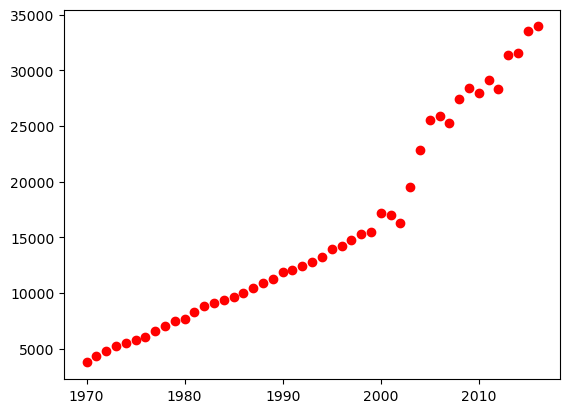

In [43]:
plt.scatter(x,y, color = 'red')

In [44]:
# take 70% of data for training and 30% for testing 
from sklearn.model_selection import train_test_split
x_train, x_test ,y_train, y_test = train_test_split(x , y, test_size=.3, random_state= 5)

In [45]:
# train the computer using simple linear LinearRegression model 
from sklearn.linear_model import LinearRegression
ref = LinearRegression()
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
# make prediction  on test data 
y_pred = reg.predict(x_test) 
y_pred

array([[18863.72447287],
       [17502.92386414],
       [ 3894.91777678],
       [11379.32112483],
       [15461.72295103],
       [12740.12173356],
       [ 1173.31655931],
       [27708.92842966],
       [ 1853.71686368],
       [19544.12477724],
       [ 2534.11716805],
       [24987.32721218],
       [ -187.48404943],
       [14100.9223423 ],
       [ 3214.51747241]])

In [47]:
# Create a temporary DataFrame to display test years and their predictions side-by-side
import pandas as pd

results = pd.DataFrame({
    'Year': x_test.iloc[:, 0], # Takes the first column of your x_test DataFrame
    'Predicted_Value': y_pred.flatten() # y_pred is a numpy array, so flatten() works here
})

print(results)

    Year  Predicted_Value
28  1998     18863.724473
26  1996     17502.923864
6   1976      3894.917777
17  1987     11379.321125
23  1993     15461.722951
19  1989     12740.121734
2   1972      1173.316559
41  2011     27708.928430
3   1973      1853.716864
29  1999     19544.124777
4   1974      2534.117168
37  2007     24987.327212
0   1970      -187.484049
21  1991     14100.922342
5   1975      3214.517472


In [48]:
# find the r square value by comparing test data and predicted data 
from sklearn.metrics import r2_score 
r2_score(y_test,y_pred)

0.8508266073165419

In [49]:
# another way to know the score of a linear regression model 
reg.score(x_test,y_test)

0.8508266073165419

In [50]:
# predict the per capita income during the years 2020 and 2021
reg.predict([[2020], [2021]])

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[33832.53116897],
       [34512.93147333]])

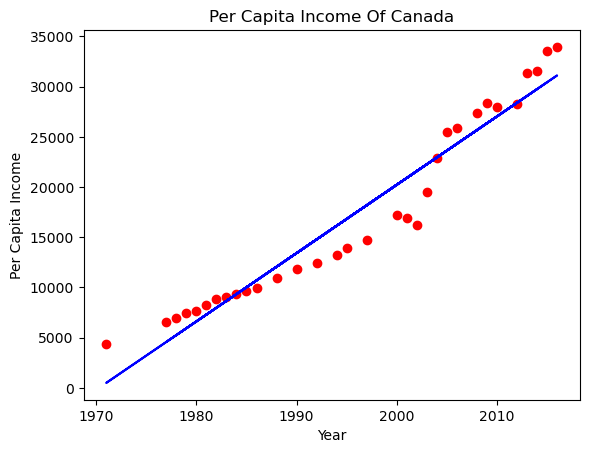

In [52]:
# draw scatter plot and regression line 
# select below block and run at once
plt.scatter(x_train, y_train, color='red')
plt.plot(x_train,reg.predict(x_train), color = 'blue') 
plt.title("Per Capita Income Of Canada") 
plt.xlabel('Year')
plt.ylabel('Per Capita Income')
plt.show()

# --End--